# Benchmark Model for Ames Housing Dataset

## Introduction

Before developing complex models, it's important to establish a simple benchmark. This gives us a baseline performance to compare against and helps us understand if our more sophisticated models are actually providing value.

In this notebook, we'll create a very simple benchmark model for predicting house prices in Ames, Iowa. The simplest possible model is to predict that every house costs the same amount - specifically, the mean sale price of all houses in our dataset.

In [1]:
# Load our preprocessed data
try:
    # Try to use IPython magic if in notebook environment
    get_ipython().run_line_magic('run', 'src/preprocessing.py')
except (NameError, AttributeError):
    # If not in notebook environment, import directly
    import sys
    import os
    sys.path.append(os.path.join(os.path.dirname(__file__), 'src'))
    from preprocessing import (
        dataset_1, dataset_2, dataset_3, dataset_4,
        target_1, target_2, target_3, target_4
    )

Remaining null values by column:
Alley           1369
MasVnrType       872
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


/Users/joshuacook/working/linalg/data/linalg/lessons/case-study-05-ames/src/preprocessing.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_df.LotFrontage.fillna(housing_df.LotFrontage.mean(), inplace=True)
/Users/joshuacook/working/linalg/data/linalg/lessons/case-study-05-ames/src/preprocessing.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the

In [2]:
# Check the shapes of our datasets to confirm they loaded correctly
print("Dataset shapes:")
print(f"Dataset 1: {dataset_1.shape}")
print(f"Dataset 2: {dataset_2.shape}")
print(f"Dataset 3: {dataset_3.shape}")
print(f"Dataset 4: {dataset_4.shape}")

Dataset shapes:
Dataset 1: (1460, 381)
Dataset 2: (1460, 389)
Dataset 3: (1453, 381)
Dataset 4: (1453, 389)


In [3]:
# Check if we need to install tqdm for progress bars
try:
    import tqdm
except ImportError:
    try:
        get_ipython().system('pip install tqdm --quiet')
    except (NameError, AttributeError):
        # Not in notebook environment
        print("Consider installing tqdm package for progress bars")

In [4]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

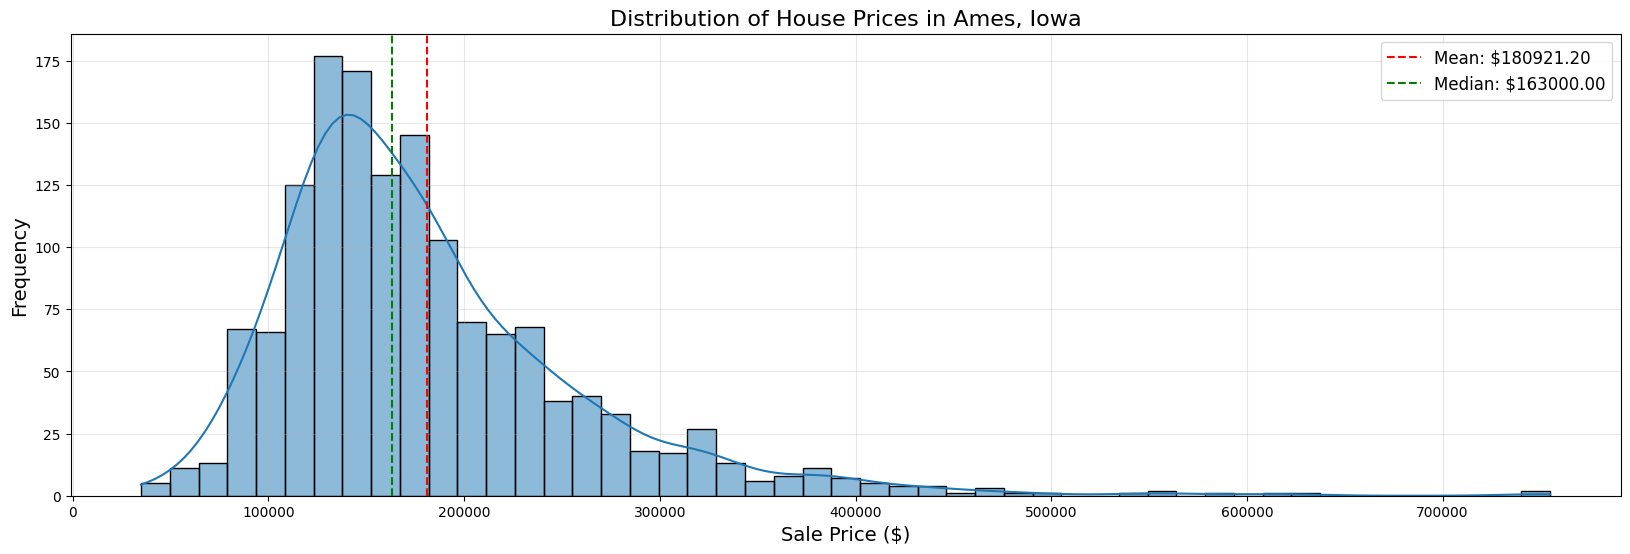

In [5]:
# Visualize the distribution of our target variable (house prices)
plt.figure(figsize=(20,6))
sns.histplot(target_1, kde=True)
plt.title('Distribution of House Prices in Ames, Iowa', fontsize=16)
plt.xlabel('Sale Price ($)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.axvline(target_1.mean(), color='red', linestyle='--', 
            label=f'Mean: ${target_1.mean():.2f}')
plt.axvline(target_1.median(), color='green', linestyle='--', 
            label=f'Median: ${target_1.median():.2f}')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.show()

## Naive Benchmark Model

Our benchmark model will simply predict the mean sale price for every house. This is the simplest possible model and requires no features.

### Fundamental Question: How much does a home in Ames, Iowa sell for?

In [6]:
# Calculate the mean and median sale price
mean_sale_price = target_1.mean()
median_sale_price = target_1.median()
print(f"Mean sale price: ${mean_sale_price:.2f}")
print(f"Median sale price: ${median_sale_price:.2f}")

# Create predictions using the mean for every house (naive model)
naive_mean_guess = np.ones(len(target_1)) * mean_sale_price
print(f"Example mean predictions: ${naive_mean_guess[:5]}")

# Create predictions using the median for every house (alternative naive model)
naive_median_guess = np.ones(len(target_1)) * median_sale_price
print(f"Example median predictions: ${naive_median_guess[:5]}")

Mean sale price: $180921.20
Median sale price: $163000.00
Example mean predictions: $[180921.19589041 180921.19589041 180921.19589041 180921.19589041
 180921.19589041]
Example median predictions: $[163000. 163000. 163000. 163000. 163000.]


## Evaluating the Benchmark Model

We'll evaluate our naive benchmark using three common metrics:

1. **R² Score**: Measures the proportion of variance in the target that is predictable from the features
2. **Root Mean Squared Error (RMSE)**: Measures the average magnitude of errors in predictions
3. **Mean Absolute Error (MAE)**: Measures the average absolute difference between predictions and actual values

In [7]:
# Evaluate the mean-based naive model
mean_r2 = r2_score(target_1, naive_mean_guess)
mean_rmse = np.sqrt(mean_squared_error(target_1, naive_mean_guess))
mean_mae = mean_absolute_error(target_1, naive_mean_guess)

print("\nMean-based Naive Model Performance:")
print(f"R² Score: {mean_r2:.4f}")
print(f"Root Mean Squared Error: ${mean_rmse:.2f}")
print(f"Mean Absolute Error: ${mean_mae:.2f}")

# Evaluate the median-based naive model
median_r2 = r2_score(target_1, naive_median_guess)
median_rmse = np.sqrt(mean_squared_error(target_1, naive_median_guess))
median_mae = mean_absolute_error(target_1, naive_median_guess)

print("\nMedian-based Naive Model Performance:")
print(f"R² Score: {median_r2:.4f}")
print(f"Root Mean Squared Error: ${median_rmse:.2f}")
print(f"Mean Absolute Error: ${median_mae:.2f}")


Mean-based Naive Model Performance:
R² Score: 0.0000
Root Mean Squared Error: $79415.29
Mean Absolute Error: $57434.77

Median-based Naive Model Performance:
R² Score: -0.0509
Root Mean Squared Error: $81412.27
Mean Absolute Error: $55533.66


## Interpretation of Results

- **R² Score**: The R² score of 0 for the mean-based model indicates that it doesn't explain any of the variance in house prices. This is expected for a naive model that always predicts the mean.

- **RMSE**: The RMSE tells us that, on average, our predictions are off by about ${mean_rmse:.2f} for the mean-based model. This is a substantial error considering the mean house price.

- **MAE**: The MAE indicates that, on average, our predictions differ from the actual prices by ${mean_mae:.2f} for the mean-based model.

- The median-based model performs similarly to the mean-based model, but may be slightly more robust to outliers in some datasets.

These metrics provide a baseline against which we can compare our more sophisticated models. Any model we develop should perform significantly better than these naive benchmarks to be considered useful.

## Visualizing the Error Distribution

Let's visualize the errors of our naive model to better understand its limitations:

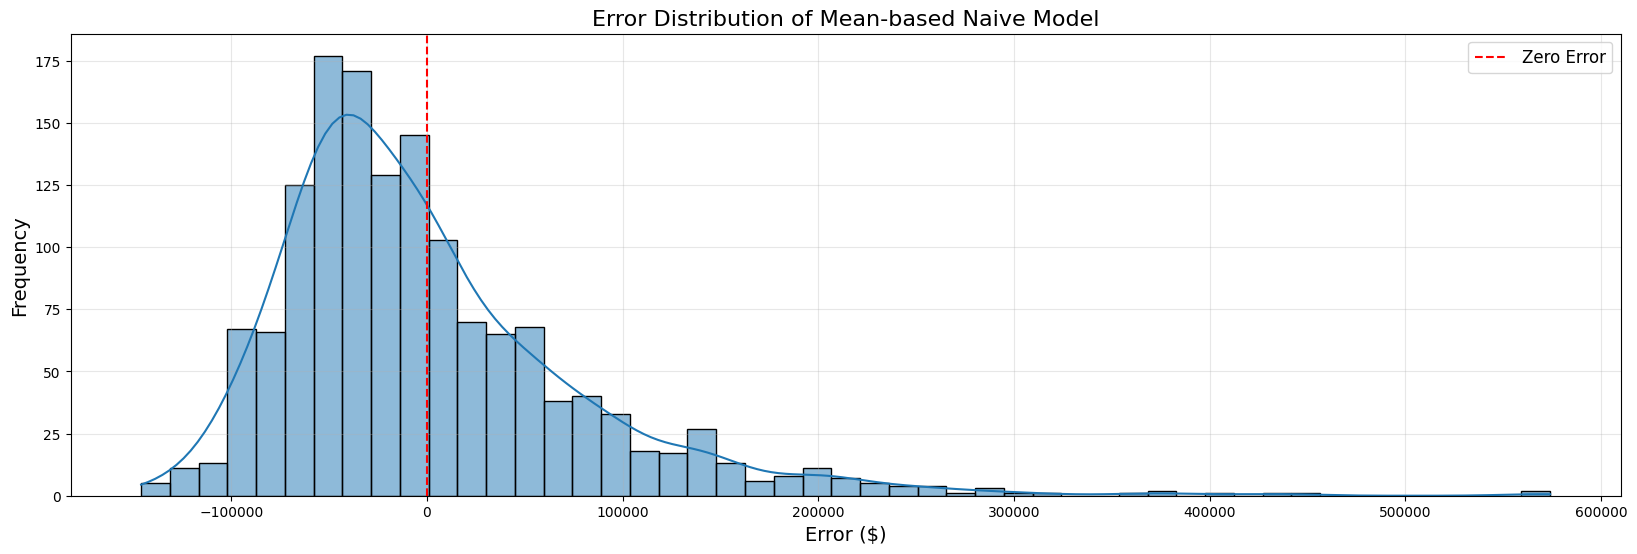

In [8]:
# Plot the error distribution of the mean-based model
errors = target_1 - naive_mean_guess
plt.figure(figsize=(20,6))
sns.histplot(errors, kde=True)
plt.title('Error Distribution of Mean-based Naive Model', fontsize=16)
plt.xlabel('Error ($)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.show()

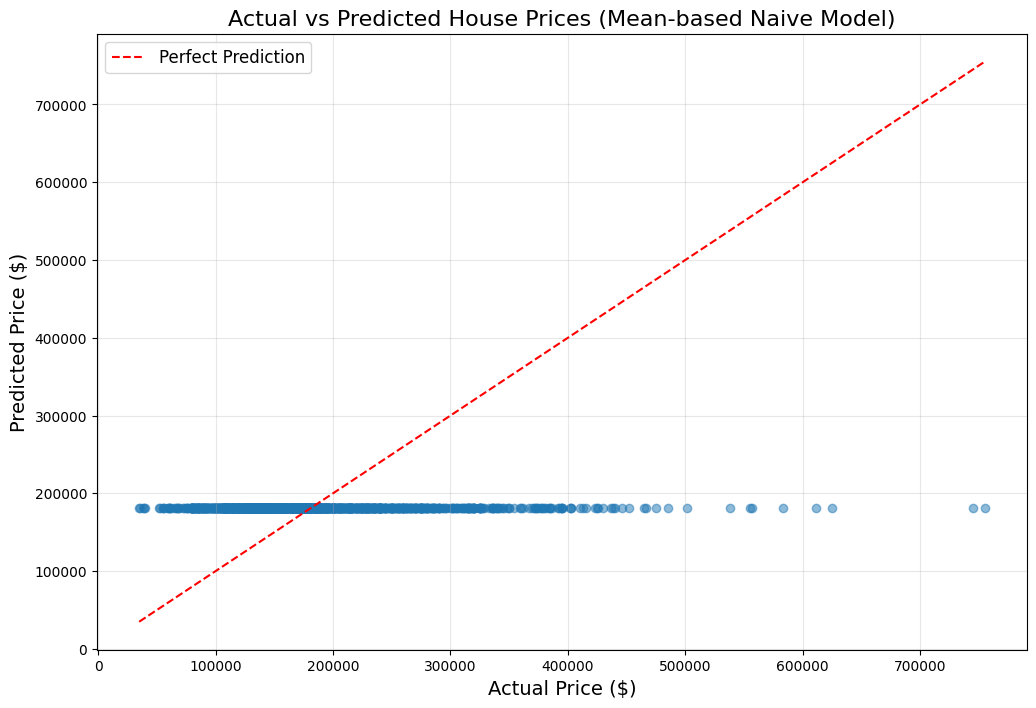

In [9]:
# Plot actual vs predicted values
plt.figure(figsize=(12,8))
plt.scatter(target_1, naive_mean_guess, alpha=0.5)
plt.plot([target_1.min(), target_1.max()], [target_1.min(), target_1.max()], 'r--', label='Perfect Prediction')
plt.title('Actual vs Predicted House Prices (Mean-based Naive Model)', fontsize=16)
plt.xlabel('Actual Price ($)', fontsize=14)
plt.ylabel('Predicted Price ($)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.show()

In the next notebooks, we'll develop more complex models using the features we've engineered and compare their performance to these benchmarks.